<a href="https://colab.research.google.com/github/G30RG3AG/novaretail-customer-behavior-analysis/blob/main/S8_Project_NovaRetail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Cargar Dataset

In [ ]:
# Cargar el dataset y explorar datos
df = df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`
-

La mayoría de estas variables presentan tipos de datos adecuados.

La columna `edad` está almacenada como tipo `float`, aunque representa edades en años completos. Por esta razón, se convierte a tipo entero (`int`) para representar correctamente la naturaleza de la variable.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [ ]:
# Corregir el tipo de dato
df["edad"] = df["edad"].astype(int)



In [ ]:

# verificar cambios
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [ ]:

# Estadísticas descriptivas de variables numéricas
variables_numericas = [
    "edad",
    "nivel_ingreso",
    "visitas_mes",
    "compras_mes",
    "gasto_publicidad_dirigida",
    "satisfaccion",
    "ingreso_anual"
]

print(df[variables_numericas].describe())



               edad  nivel_ingreso   visitas_mes   compras_mes  \
count  15000.000000   15000.000000  15000.000000  15000.000000   
mean      38.262400   30019.704782     10.029000      1.206467   
std       11.492378    9833.166305      3.158189      1.105284   
min       18.000000    8000.000000      1.000000      0.000000   
25%       30.000000   23127.097500      8.000000      0.000000   
50%       38.000000   30023.745000     10.000000      1.000000   
75%       46.000000   36768.440000     12.000000      2.000000   
max       75.000000   74790.840000     25.000000      8.000000   

       gasto_publicidad_dirigida  satisfaccion  ingreso_anual  
count               15000.000000  15000.000000   15000.000000  
mean                   20.149301      3.603693      36.594180  
std                    10.880724      0.685300      34.484888  
min                     0.000000      1.000000       0.000000  
25%                    12.310000      3.100000       0.000000  
50%                  

✍️ **Comentario**:
Diagnóstico inicial de variables numéricas

- `edad` — La edad promedio de los clientes es de aproximadamente 38.26 años, con una mediana de 38 años. Los valores van de 18 a 75 años, por lo que no se observan edades fuera de un rango razonable.

- `nivel_ingreso` — El ingreso estimado promedio es de aproximadamente 30,019.70, con una mediana de 30,023.75. Los valores oscilan entre 8,000 y 74,790.84. La media y la mediana son muy similares, lo que sugiere que la distribución no presenta una asimetría pronunciada.

- `visitas_mes` — Los clientes realizan en promedio 10.03 visitas al mes, con una mediana de 10 visitas. Los valores van de 1 a 25 visitas mensuales, mostrando distintos niveles de interacción con la plataforma.

- `compras_mes` — El promedio es de aproximadamente 1.21 compras mensuales, con una mediana de 1. El 25% de los clientes no realiza compras durante el mes y el valor máximo registrado es de 8 compras, lo que indica que una parte importante de los usuarios tiene una actividad de compra baja.

- `gasto_publicidad_dirigida` — El gasto promedio asignado por cliente es de aproximadamente 20.15, con una mediana de 19.73. Existen clientes con gasto igual a 0 y un valor máximo de 75.51, lo que muestra una dispersión considerable en la inversión publicitaria dirigida.

- `satisfaccion` — La satisfacción promedio es de aproximadamente 3.60 puntos, con una mediana de 3.6. Los valores se encuentran dentro de la escala esperada de 1 a 5, por lo que no se observan valores fuera de rango.

- `ingreso_anual` — El ingreso anual promedio generado por cliente es de aproximadamente 36.59, con una mediana de 30.71. El valor mínimo es 0 y el máximo alcanza 244.69. La diferencia entre la media y la mediana, junto con el valor máximo elevado, sugiere una posible asimetría positiva y la presencia de clientes que generan ingresos considerablemente mayores que el resto.

#### Explorar variables binarias

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles
print("miembro_premium:")
print(df["miembro_premium"].value_counts())
print()

print("abandono:")
print(df["abandono"].value_counts())


miembro_premium:
0    12911
1     2089
Name: miembro_premium, dtype: int64

abandono:
0    12739
1     2261
Name: abandono, dtype: int64


✍️ **Comentario**:

Diagnóstico inicial de variables binarias

- `miembro_premium` — La variable contiene únicamente los valores 0 y 1, donde 0 representa clientes sin suscripción premium y 1 representa clientes premium. Su distribución permite observar qué proporción aproximada de clientes pertenece a cada grupo.

- `abandono` — La variable contiene únicamente los valores 0 y 1, donde 0 representa clientes que permanecen en la plataforma y 1 representa clientes que la abandonaron. Su distribución permite identificar si existe un desbalance entre clientes activos y clientes que abandonaron.

#### Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
print("Valores únicos tipo_dispositivo:", df["tipo_dispositivo"].nunique())
print("Valores únicos region:", df["region"].nunique())

print()


Valores únicos tipo_dispositivo: 3
Valores únicos region: 4



In [ ]:
# Explorar variables categóricas y cómo se distribuyen
print("Distribución de tipo_dispositivo:")
print(df["tipo_dispositivo"].value_counts())

print()

print("Distribución de region:")
print(df["region"].value_counts())

Distribución de tipo_dispositivo:
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

Distribución de region:
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


In [ ]:

df[variables_numericas].describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


✍️ **Comentario**:

Diagnóstico inicial de variables categóricas

- `miembro_premium` — La variable contiene únicamente los valores 0 y 1, donde 0 representa clientes sin suscripción premium y 1 representa clientes premium. Su distribución permite observar qué proporción aproximada de clientes pertenece a cada grupo.

- `abandono` — La variable contiene únicamente los valores 0 y 1, donde 0 representa clientes que permanecen en la plataforma y 1 representa clientes que la abandonaron. Su distribución permite identificar si existe un desbalance entre clientes activos y clientes que abandonaron.


### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

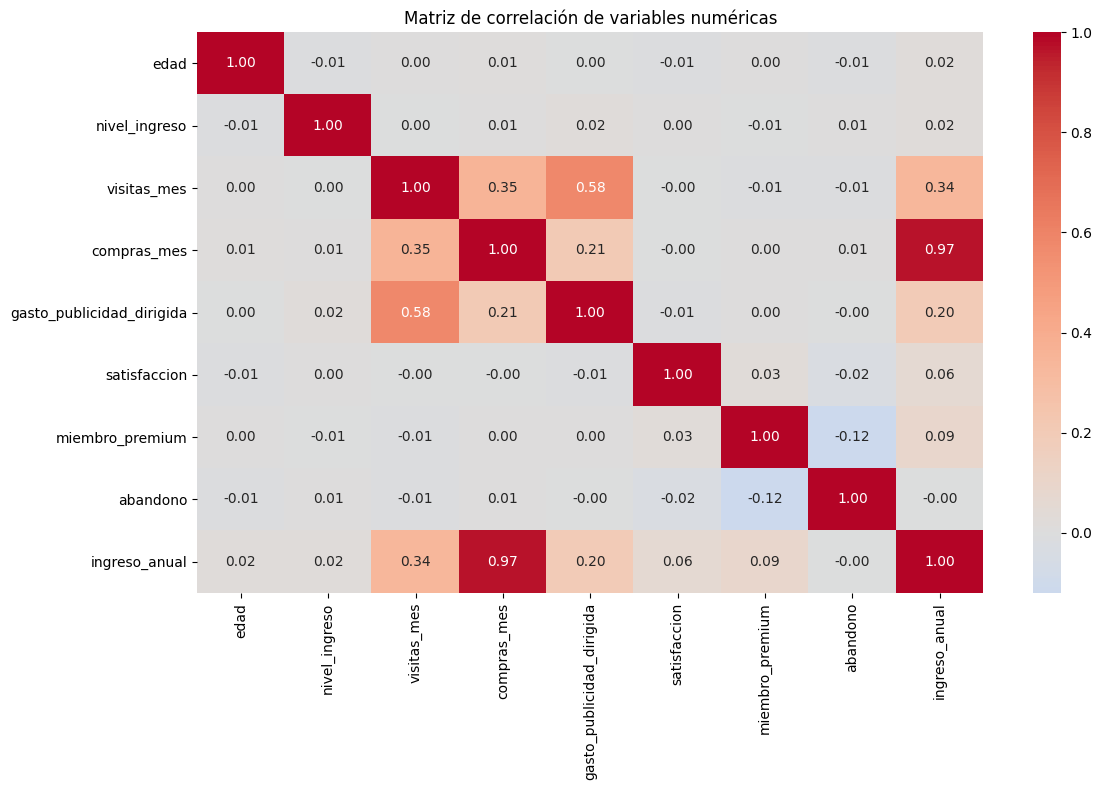

In [ ]:
# Visualizar la matriz de correlación para identificar relaciones
# Seleccionar variables numéricas
variables_numericas = [
    "edad",
    "nivel_ingreso",
    "visitas_mes",
    "compras_mes",
    "gasto_publicidad_dirigida",
    "satisfaccion",
    "miembro_premium",
    "abandono",
    "ingreso_anual"
]

# Calcular matriz de correlación
matriz_correlacion = df[variables_numericas].corr()

# Visualizar la matriz de correlación
plt.figure(figsize=(12, 8))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()

✍️ **Comentario**:

**Observaciones generales (Heatmap)**  
- Se observa que la mayoría de las variables presentan correlaciones débiles o cercanas a cero, por lo que no existe una relación lineal fuerte entre gran parte de ellas.
- La relación más alta del conjunto se presenta entre `compras_mes` e `ingreso_anual`, con una correlación de aproximadamente **0.97**, lo que indica una relación positiva muy fuerte.
- También se observa una relación positiva moderada entre `visitas_mes` y `gasto_publicidad_dirigida` (**0.58**).
- `visitas_mes` y `compras_mes` presentan una correlación positiva moderada de aproximadamente **0.35**.
- `gasto_publicidad_dirigida` y `compras_mes` muestran una relación positiva débil de aproximadamente **0.21**.
- La mayoría de las demás relaciones son muy bajas, cercanas a cero.
- Entre `miembro_premium` y `abandono` se observa una correlación negativa débil de aproximadamente **-0.12**.

**Observaciones respecto a `ingreso_anual`**  
- Presenta una correlación positiva muy fuerte con `compras_mes` (**0.97**), lo que sugiere que los clientes que realizan más compras tienden a generar mayores ingresos para la empresa.
- Tiene una correlación positiva moderada con `visitas_mes` (**0.34**), indicando que una mayor actividad en la plataforma se asocia parcialmente con mayores ingresos.
- La relación con `gasto_publicidad_dirigida` es positiva pero débil (**0.20**).
- `miembro_premium` presenta una correlación positiva débil con `ingreso_anual` (**0.09**).
- `satisfaccion` muestra una relación positiva muy débil (**0.06**).
- `edad` y `nivel_ingreso` presentan correlaciones prácticamente nulas con `ingreso_anual` (**0.02** en ambos casos).
- `abandono` presenta una correlación prácticamente nula con `ingreso_anual`, por lo que no se observa una relación lineal directa relevante en este análisis.

### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.

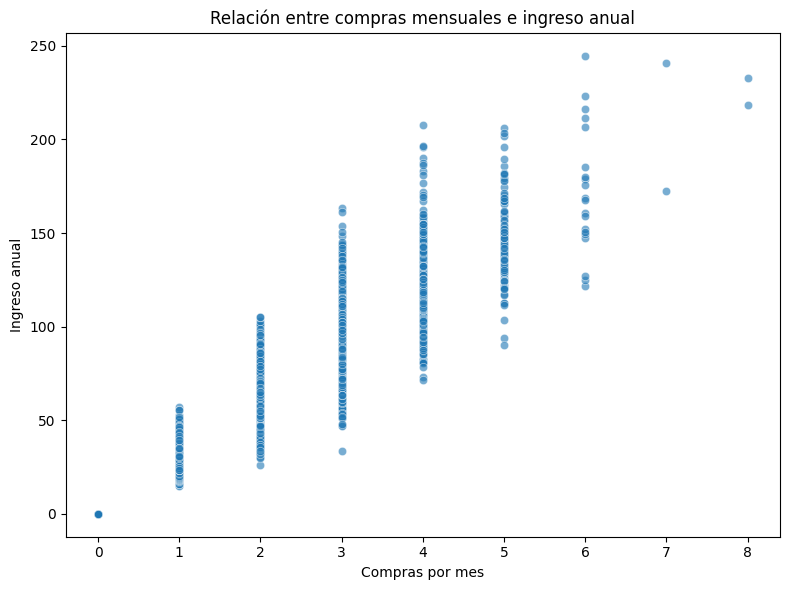

In [ ]:
# Scatterplot general
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="compras_mes",
    y="ingreso_anual",
    alpha=0.6
)

plt.title("Relación entre compras mensuales e ingreso anual")
plt.xlabel("Compras por mes")
plt.ylabel("Ingreso anual")
plt.tight_layout()
plt.show()

**Comentario:**

Se decidió incluir un scatterplot entre `compras_mes` e `ingreso_anual` debido a que esta relación presentó la correlación más alta del heatmap, con un valor aproximado de **0.97**.

El gráfico permite observar visualmente una tendencia positiva clara: conforme aumenta el número de compras mensuales, también tiende a aumentar el `ingreso_anual` generado por el cliente.

La concentración de los puntos alrededor de una tendencia ascendente es consistente con la fuerte correlación identificada previamente. También permite detectar posibles valores extremos o clientes cuyo ingreso anual se aleje del comportamiento general.

Este resultado muestra una asociación fuerte entre ambas variables, aunque por sí solo no permite afirmar una relación causal.

### Scatterplot para pares clave

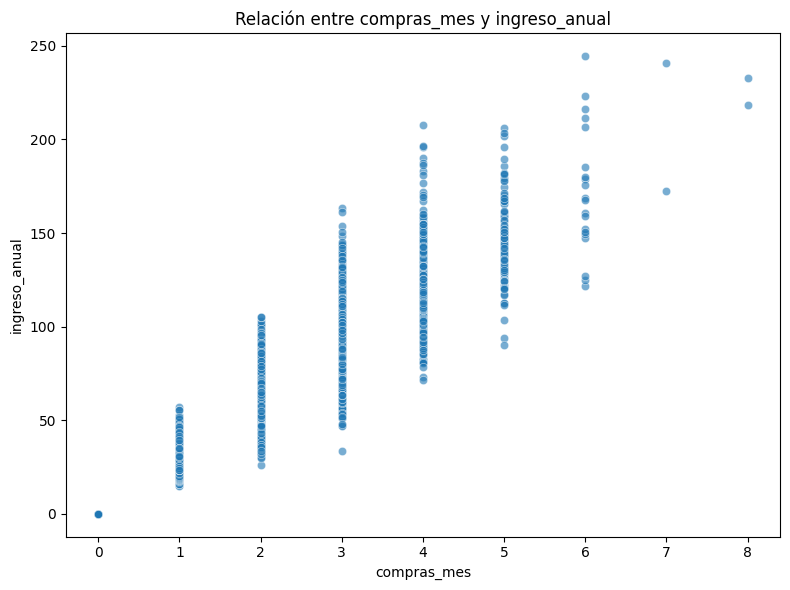

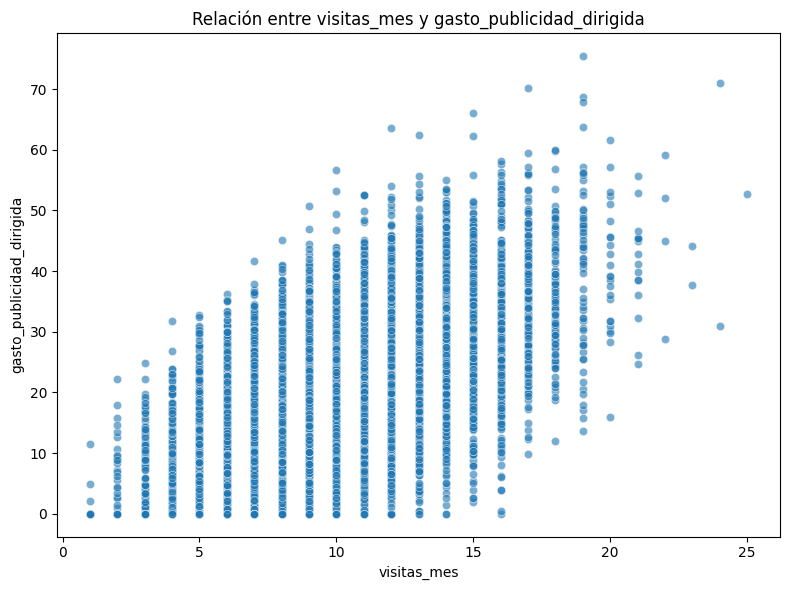

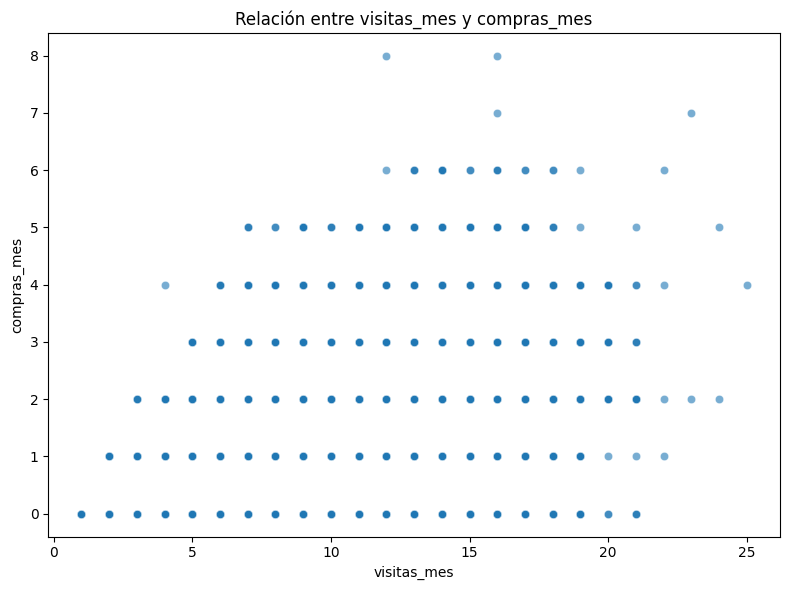

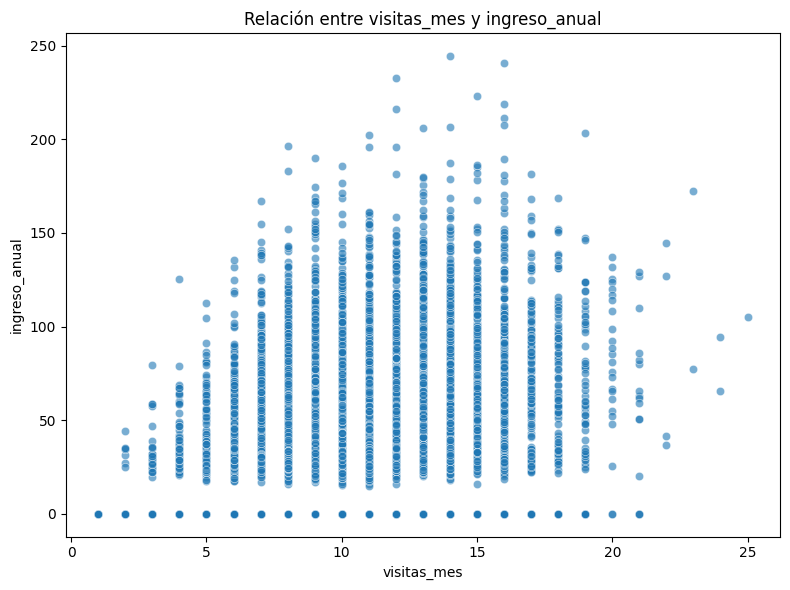

In [ ]:
# Visualizar pares de variables con relaciones moderadas o fuertes

pares_clave = [
    ("compras_mes", "ingreso_anual"),
    ("visitas_mes", "gasto_publicidad_dirigida"),
    ("visitas_mes", "compras_mes"),
    ("visitas_mes", "ingreso_anual")
]

for x, y in pares_clave:
    plt.figure(figsize=(8, 6))

    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        alpha=0.6
    )

    plt.title(f"Relación entre {x} y {y}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.tight_layout()
    plt.show()

✍️ **Comentario**:


### Observaciones iniciales (Scatterplot)

**`compras_mes` vs `ingreso_anual`**

- Dirección **positiva y muy fuerte**: conforme aumenta el número de compras mensuales, el `ingreso_anual` tiende a incrementarse claramente.
- La dispersión es **baja a moderada** dentro de cada nivel de compras, aunque aumenta ligeramente en los niveles más altos.
- Se observan algunos valores elevados de `ingreso_anual`, principalmente entre clientes con 6 a 8 compras mensuales, que podrían considerarse posibles valores atípicos y deberían revisarse posteriormente.
- La relación coincide con la correlación de aproximadamente **0.97** observada en el heatmap.
- Esta relación es especialmente relevante para explicar `ingreso_anual`; al tratarse de la variable objetivo del análisis, no representa por sí misma un problema de colinealidad entre variables explicativas.

**`visitas_mes` vs `gasto_publicidad_dirigida`**

- Dirección **positiva moderada**: a mayor número de visitas mensuales, generalmente se observa un mayor gasto en publicidad dirigida.
- La dispersión es **media** y aumenta conforme crece el número de visitas.
- Se observan algunos registros alejados de la concentración principal, especialmente con gastos publicitarios superiores a aproximadamente 60–75, que pueden considerarse posibles outliers.
- La correlación de aproximadamente **0.58** confirma una asociación moderada.
- Existe cierta relación entre ambas variables, pero no es suficientemente alta para señalar una colinealidad fuerte.

**`visitas_mes` vs `compras_mes`**

- Dirección **positiva**, aunque menos marcada que en los pares anteriores.
- La dispersión es **media-alta**: clientes con cantidades similares de visitas pueden realizar diferentes números de compras.
- Se observan pocos registros con 7 u 8 compras mensuales, que son poco frecuentes respecto al resto de los datos y conviene revisar como posibles valores extremos.
- La correlación de aproximadamente **0.35** indica una relación positiva moderada-débil.
- No se observa evidencia de colinealidad importante entre ambas variables.

**`visitas_mes` vs `ingreso_anual`**

- Dirección **positiva moderada-débil**: en términos generales, mayores niveles de visitas se relacionan con mayores ingresos, aunque el patrón presenta bastante variabilidad.
- La dispersión es **alta**, ya que para un mismo número de visitas aparecen clientes con niveles muy diferentes de `ingreso_anual`.
- Se observan algunos valores elevados de ingreso, superiores a 200, que podrían considerarse posibles outliers.
- La correlación de aproximadamente **0.34** respalda la presencia de una asociación positiva, pero considerablemente más débil que la encontrada entre `compras_mes` e `ingreso_anual`.
- No se aprecia un problema de colinealidad a partir de esta relación.

### Conclusión

Los scatterplots confirman los patrones observados previamente en el heatmap. La relación más clara se encuentra entre `compras_mes` e `ingreso_anual`, mientras que `visitas_mes` mantiene asociaciones positivas de distinta intensidad con las demás variables. No se identifican relaciones entre variables explicativas lo suficientemente altas como para indicar un problema evidente de colinealidad. También se observan algunos valores extremos potenciales que pueden analizarse con mayor detalle en etapas posteriores.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [ ]:
# Calcular correlación entre variables relevantes

pares_relevantes = [
    ("compras_mes", "ingreso_anual"),
    ("visitas_mes", "gasto_publicidad_dirigida"),
    ("visitas_mes", "compras_mes"),
    ("visitas_mes", "ingreso_anual")
]

for var1, var2 in pares_relevantes:
    pearson = df[var1].corr(df[var2], method="pearson")
    spearman = df[var1].corr(df[var2], method="spearman")

    print(f"{var1} vs {var2}")
    print("Pearson:", round(pearson, 3))
    print("Spearman:", round(spearman, 3))
    print()


compras_mes vs ingreso_anual
Pearson: 0.967
Spearman: 0.967

visitas_mes vs gasto_publicidad_dirigida
Pearson: 0.579
Spearman: 0.559

visitas_mes vs compras_mes
Pearson: 0.354
Spearman: 0.333

visitas_mes vs ingreso_anual
Pearson: 0.337
Spearman: 0.321



✍️ **Comentario**:

Observaciones de correlación:

**`compras_mes` vs `ingreso_anual`**

- Correlación **positiva muy fuerte**.
- Pearson = **0.967** y Spearman = **0.967**, por lo que ambos métodos muestran prácticamente la misma intensidad.
- Esto indica una relación muy consistente y aproximadamente lineal: a mayor número de compras mensuales, mayor tiende a ser el `ingreso_anual`.
- Debido a que `ingreso_anual` es la métrica principal del análisis y `compras_mes` es una variable explicativa, esta relación no representa por sí misma un problema de colinealidad entre predictores.

**`visitas_mes` vs `gasto_publicidad_dirigida`**

- Correlación **positiva moderada**.
- Pearson = **0.579** y Spearman = **0.559**.
- Ambos coeficientes son similares, lo que indica que la relación positiva se mantiene de forma relativamente consistente.
- La magnitud no es lo suficientemente alta como para considerar una colinealidad fuerte, aunque sí existe una asociación relevante entre ambas variables.

**`visitas_mes` vs `compras_mes`**

- Correlación **positiva débil a moderada**.
- Pearson = **0.354** y Spearman = **0.333**.
- Los valores son cercanos entre sí, por lo que la relación observada es relativamente estable, aunque con bastante dispersión.
- No se identifica evidencia de colinealidad importante entre estas variables.

**`visitas_mes` vs `ingreso_anual`**

- Correlación **positiva débil a moderada**.
- Pearson = **0.337** y Spearman = **0.321**.
- Ambos coeficientes presentan valores similares, indicando que existe una asociación positiva consistente, pero de menor intensidad.
- Una mayor cantidad de visitas tiende a relacionarse con mayores ingresos, aunque esta relación es considerablemente más débil que la encontrada entre `compras_mes` e `ingreso_anual`.
- No se observa un problema de colinealidad.

### Conclusión

Los coeficientes de Pearson y Spearman presentan valores muy similares en todos los pares analizados, lo que indica que las relaciones detectadas son relativamente consistentes y no dependen únicamente de valores extremos.

La asociación más relevante es `compras_mes` con `ingreso_anual`, con un coeficiente de **0.967**, mientras que las demás relaciones presentan magnitudes moderadas o débiles. Entre las variables explicativas analizadas no se observan correlaciones suficientemente altas como para indicar un problema evidente de colinealidad.

### Punto-biserial

In [ ]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr

# Correlación punto-biserial: miembro_premium vs ingreso_anual
corr_premium, p_premium = pointbiserialr(
    df["miembro_premium"],
    df["ingreso_anual"]
)

# Correlación punto-biserial: abandono vs ingreso_anual
corr_abandono, p_abandono = pointbiserialr(
    df["abandono"],
    df["ingreso_anual"]
)

print("miembro_premium vs ingreso_anual")
print("Correlación punto-biserial:", round(corr_premium, 3))
print("p-value:", round(p_premium, 5))
print()

print("abandono vs ingreso_anual")
print("Correlación punto-biserial:", round(corr_abandono, 3))
print("p-value:", round(p_abandono, 5))


miembro_premium vs ingreso_anual
Correlación punto-biserial: 0.093
p-value: 0.0

abandono vs ingreso_anual
Correlación punto-biserial: -0.003
p-value: 0.72947


✍️ **Comentario**:

Observaciones Punto-biserial

**`miembro_premium` vs `ingreso_anual`**

- Relación **positiva débil**.
- El coeficiente punto-biserial es de aproximadamente **0.093**, por lo que la asociación entre ser miembro premium y el `ingreso_anual` es baja.
- El `p-value` es prácticamente **0**, lo que indica que la relación es estadísticamente significativa.
- Sin embargo, la magnitud del coeficiente es pequeña, por lo que el efecto observado es débil.

**`abandono` vs `ingreso_anual`**

- Relación **negativa prácticamente nula**.
- El coeficiente punto-biserial es de aproximadamente **-0.003**, lo que indica que prácticamente no existe asociación entre `abandono` e `ingreso_anual`.
- El `p-value` es aproximadamente **0.72947**, por lo que esta relación no es estadísticamente significativa.
- En términos prácticos, el abandono no muestra una relación relevante con el ingreso anual en este análisis.

### Conclusión

La variable `miembro_premium` presenta una asociación positiva pero débil con `ingreso_anual`, mientras que `abandono` no muestra una relación relevante. Por lo tanto, ninguna de las dos variables binarias presenta una magnitud alta o moderada respecto al ingreso anual.

### V de Cramér

In [ ]:
# Función para calcular V de Cramér
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

# Función para calcular V de Cramér
def cramers_v(df, col_1, col_2):
    tabla = pd.crosstab(df[col_1], df[col_2])

    chi2, _, _, _ = chi2_contingency(tabla)

    n = tabla.sum().sum()

    coef_v = np.sqrt(
        chi2 / (
            n * min(
                tabla.shape[0] - 1,
                tabla.shape[1] - 1
            )
        )
    )

    return coef_v

In [ ]:
# Aplicar V de Cramér en variables relevantes
pares_categoricos = [
    ("tipo_dispositivo", "region"),
    ("tipo_dispositivo", "miembro_premium"),
    ("tipo_dispositivo", "abandono"),
    ("region", "miembro_premium"),
    ("region", "abandono"),
    ("miembro_premium", "abandono")
]

for var1, var2 in pares_categoricos:
    v = cramers_v(df, var1, var2)

    print(f"{var1} vs {var2}")
    print("V de Cramér:", round(v, 3))
    print()


tipo_dispositivo vs region
V de Cramér: 0.012

tipo_dispositivo vs miembro_premium
V de Cramér: 0.02

tipo_dispositivo vs abandono
V de Cramér: 0.007

region vs miembro_premium
V de Cramér: 0.013

region vs abandono
V de Cramér: 0.015

miembro_premium vs abandono
V de Cramér: 0.12



✍️ **Comentario**:

### Observaciones V de Cramér

- `tipo_dispositivo` vs `region` — V de Cramér = **0.012**. La asociación es prácticamente nula, por lo que el tipo de dispositivo utilizado no parece estar relacionado de forma relevante con la región.

- `tipo_dispositivo` vs `miembro_premium` — V de Cramér = **0.020**. La relación es muy débil, indicando que el tipo de dispositivo no tiene una asociación importante con el hecho de ser miembro premium.

- `tipo_dispositivo` vs `abandono` — V de Cramér = **0.007**. La asociación es prácticamente inexistente, por lo que no se observa una relación relevante entre el dispositivo utilizado y el abandono de la plataforma.

- `region` vs `miembro_premium` — V de Cramér = **0.013**. La asociación es muy débil, lo que sugiere que la región no está relacionada de manera importante con la suscripción premium.

- `region` vs `abandono` — V de Cramér = **0.015**. La relación es prácticamente nula, por lo que no se identifica una asociación relevante entre la región y el abandono.

- `miembro_premium` vs `abandono` — V de Cramér = **0.120**. Es la asociación más alta entre los pares analizados, aunque sigue siendo débil. Esto sugiere que existe cierta relación entre ser miembro premium y el abandono, pero la magnitud no es suficiente para considerarla fuerte o moderada.

### Conclusión

En general, las variables categóricas analizadas presentan asociaciones muy bajas. La relación más destacada es `miembro_premium` vs `abandono`, con un V de Cramér de **0.120**, aunque su magnitud continúa siendo débil. Por lo tanto, no se observan asociaciones categóricas fuertes dentro de los pares evaluados.


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

Hallazgo 1 — Las compras mensuales están fuertemente asociadas con el ingreso anual

**Evidencia visual:**  
El scatterplot entre `compras_mes` e `ingreso_anual` muestra una tendencia ascendente clara. A medida que aumenta el número de compras mensuales, también tiende a aumentar el ingreso generado por el cliente.

**Evidencia numérica:**  
La correlación de Pearson entre `compras_mes` e `ingreso_anual` es de **0.967** y la correlación de Spearman también es de **0.967**, lo que indica una asociación positiva muy fuerte y consistente.

**Interpretación**  
Los clientes que realizan más compras al mes tienden a generar mayores niveles de `ingreso_anual`. La similitud entre Pearson y Spearman refuerza que esta relación es estable y no depende únicamente de una forma lineal específica.

**No podemos afirmar**  
No podemos afirmar que realizar más compras sea la causa directa de un mayor ingreso anual, ya que el análisis realizado es correlacional y pueden existir otros factores que influyan en ambas variables.

**Implicación de negocio**  
`compras_mes` puede considerarse una variable especialmente relevante para identificar clientes de mayor valor económico. NovaRetail+ podría utilizar esta información para segmentar clientes por frecuencia de compra y diseñar estrategias orientadas a aumentar recurrencia, recompra y retención de clientes con alto potencial de ingreso.



### 5.2. Hallazgo 2 — La condición de miembro premium presenta una asociación débil con el abandono

**Evidencia visual:**  
El heatmap muestra una relación negativa débil entre `miembro_premium` y `abandono`, aunque visualmente la intensidad es baja.

**Evidencia numérica:**  
La correlación observada en el heatmap entre `miembro_premium` y `abandono` es aproximadamente **-0.12**. Además, el V de Cramér entre ambas variables es de **0.120**, siendo la asociación categórica más alta entre los pares analizados, aunque sigue siendo débil.

**Interpretación**  
Existe una asociación débil entre ser miembro premium y el comportamiento de abandono. El signo negativo observado en la correlación sugiere que los miembros premium tienden ligeramente a presentar menor abandono, aunque la relación es pequeña.

**No podemos afirmar**  
No podemos afirmar que la suscripción premium reduzca directamente el abandono. Tampoco se puede concluir que convertir a un cliente en premium provoque una mejora en retención, ya que podrían intervenir otras características del cliente.

**Implicación de negocio**  
La membresía premium podría considerarse como una variable complementaria en análisis de retención, pero no debería utilizarse por sí sola para predecir abandono. Sería conveniente combinarla con otras variables de comportamiento, como frecuencia de compra, visitas y satisfacción, para construir segmentos de riesgo más completos.


## Sección 6 - Limitaciones y próximos pasos

### 6.1. Limitaciones

- **Correlación ≠ causalidad.** Las relaciones encontradas muestran asociación entre variables, pero no permiten concluir que una variable cause directamente cambios en otra.
- El análisis se basa en un solo conjunto de datos y en un periodo específico, por lo que los patrones observados podrían cambiar en otros periodos o poblaciones de clientes.
- Algunas relaciones presentan coeficientes bajos aunque sean estadísticamente significativos, por lo que su relevancia práctica puede ser limitada.
- Las variables categóricas analizadas mediante V de Cramér mostraron asociaciones principalmente débiles, por lo que pueden existir otros factores no incluidos en el dataset que expliquen mejor el comportamiento de los clientes.
- Se identificaron posibles valores extremos en variables como `ingreso_anual` y `gasto_publicidad_dirigida`, los cuales podrían influir en ciertos resultados.
- El análisis realizado es principalmente bivariado, por lo que cada relación se estudió de manera individual sin controlar simultáneamente el efecto de otras variables.



### 6.2. Próximos pasos

**Probar segmentación adicional**

- Segmentar a los clientes por nivel de compras (`compras_mes`) para comparar el comportamiento de clientes con baja, media y alta frecuencia de compra.
- Analizar los resultados por `miembro_premium`, `region` y `tipo_dispositivo` para identificar si las relaciones cambian entre distintos grupos de clientes.

**Profundizar en el análisis de ingreso**

- Analizar con mayor detalle los posibles valores atípicos de `ingreso_anual` mediante histogramas y boxplots.
- Comparar el ingreso promedio y mediano entre diferentes segmentos de clientes para identificar grupos de mayor valor económico.

**Desarrollar análisis predictivos**

- Construir un modelo para estimar `ingreso_anual` utilizando variables como `compras_mes`, `visitas_mes`, `gasto_publicidad_dirigida` y `miembro_premium`.
- Evaluar por separado un modelo de clasificación para identificar clientes con mayor probabilidad de `abandono`.
- Comparar el desempeño de los modelos con métricas adecuadas antes de utilizarlos para apoyar decisiones de negocio.